##### Practica de un dataset de kfc

### Importamos las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Tenemos que leer y analizar el dataset

In [ ]:
df = pd.read_csv("dataset/KFC_Past_Sales_Dataset.csv")

In [ ]:
df.head()

,Year,Month,Country,Branch_ID,Sales,Customers,Marketing_Spend
0,2022,Aug,UK,KFC_UK_01,206611,4568,23891
1,2018,May,India,KFC_IN_01,69645,1715,6190
2,2020,Nov,UK,KFC_UK_01,170226,4672,6706
3,2024,Dec,Australia,KFC_AU_01,90483,2363,17230
4,2019,Nov,UK,KFC_UK_01,94260,2207,28050


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             8000 non-null   int64
 1   Month            8000 non-null   str  
 2   Country          8000 non-null   str  
 3   Branch_ID        8000 non-null   str  
 4   Sales            8000 non-null   int64
 5   Customers        8000 non-null   int64
 6   Marketing_Spend  8000 non-null   int64
dtypes: int64(4), str(3)
memory usage: 437.6 KB


In [ ]:
df.describe()

,Year,Sales,Customers,Marketing_Spend
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,2021.010875,148837.878625,3737.376875,17557.908250
std,2.002813,52360.720217,1306.584933,7183.115842
min,2018.000000,45193.000000,1500.000000,5001.000000
25%,2019.000000,105914.500000,2609.000000,11310.000000
50%,2021.000000,144951.500000,3724.000000,17642.500000
75%,2023.000000,185739.250000,4885.000000,23716.500000
max,2024.000000,293162.000000,6000.000000,30000.000000


Ver si hay datos nulos 

Aqui visualizamos los paises y sucursales que hay

In [ ]:
df['Country'].value_counts()

Country
Canada       1669
UK           1619
India        1592
Australia    1582
USA          1538
Name: count, dtype: int64

In [ ]:
df['Branch_ID']

0       KFC_UK_01
1       KFC_IN_01
2       KFC_UK_01
3       KFC_AU_01
4       KFC_UK_01
          ...    
7995    KFC_US_01
7996    KFC_UK_01
7997    KFC_UK_02
7998    KFC_CA_01
7999    KFC_CA_02
Name: Branch_ID, Length: 8000, dtype: str

Ver si hay datos nulos

In [ ]:
df.isnull().sum()

Year               0
Month              0
Country            0
Branch_ID          0
Sales              0
Customers          0
Marketing_Spend    0
dtype: int64

Mostrar cuantas sucursales distintas hay en total

In [ ]:
df['Branch_ID'].nunique()

13

In [ ]:
# Saber saber si los meses estan en texto
df['Month'].unique()

<StringArray>
['Aug', 'May', 'Nov', 'Dec', 'Sep', 'Oct', 'Mar', 'Jun', 'Apr', 'Jul', 'Feb',
 'Jan']
Length: 12, dtype: str

In [ ]:
#Creamos una columna para ver la fecha real
df['Fecha'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str), format='%b %Y')

In [ ]:
df.groupby('Country')['Sales'].mean().sort_values(ascending=False)

Country
UK           150254.804200
India        149634.118090
Australia    148778.761694
Canada       148195.669263
USA          147279.851756
Name: Sales, dtype: float64

In [ ]:
#Sacamos la correlacion entre ventas, marketing y clientes

df[['Sales', 'Marketing_Spend', 'Customers']].corr()

,Sales,Marketing_Spend,Customers
Sales,1.000000,0.152775,0.876443
Marketing_Spend,0.152775,1.000000,0.009253
Customers,0.876443,0.009253,1.000000


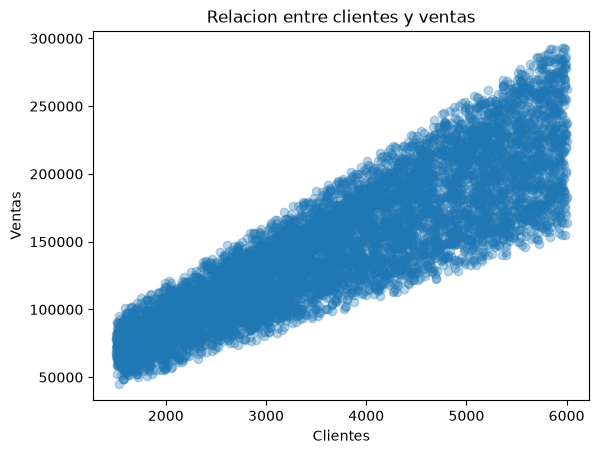

In [ ]:
#Graficamos 

plt.scatter(df['Customers'], df['Sales'], alpha=0.3)
plt.xlabel('Clientes')
plt.ylabel('Ventas')
plt.title("Relacion entre clientes y ventas")
plt.show()

In [ ]:
# Creamos una columnas relacionando ventas con clientes

df['Ticket_promedio'] = df['Sales'] / df['Customers']
df['Ticket_promedio']

0       45.230079
1       40.609329
2       36.435360
3       38.291579
4       42.709560
          ...    
7995    28.976298
7996    31.411981
7997    37.010035
7998    38.954370
7999    31.038117
Name: Ticket_promedio, Length: 8000, dtype: float64

In [ ]:
# Agrupamos por los anos
(df.groupby(df['Fecha'].dt.year)['Sales'].sum())

Fecha
2018    168697492
2019    170833341
2020    170540121
2021    170897519
2022    169806190
2023    164978857
2024    174949509
Name: Sales, dtype: int64